In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize

df = pd.read_csv('/workspaces/k-means-repo/data/processed/cleaned_data_before_scaling.csv')

# Normalize data for cosine similarity
df_normalized = normalize(df)

the two methods to find the best k

1. Elbow method → plot inertia vs K → look for the bend
2. Silhouette score → measure cluster quality → higher is better

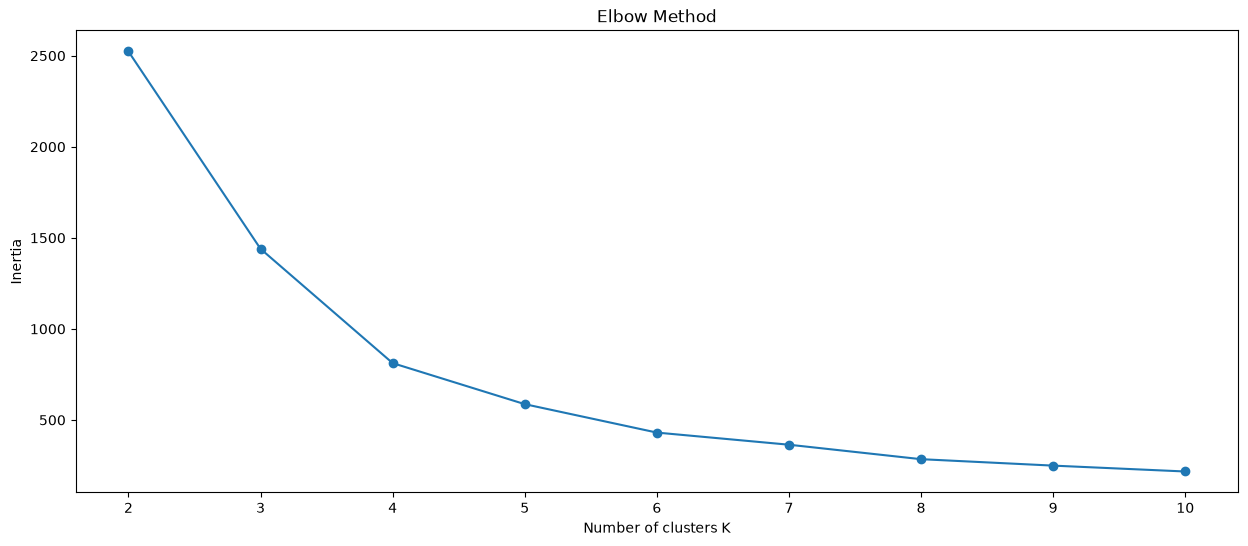

In [68]:
inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_normalized)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(15, 6))
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters K')
plt.ylabel('Inertia')
plt.show()

K=2 done, score=0.6561
K=3 done, score=0.5894
K=4 done, score=0.5296
K=5 done, score=0.5272
K=6 done, score=0.5017
K=7 done, score=0.4858
K=8 done, score=0.4868
K=9 done, score=0.4782
K=10 done, score=0.4589


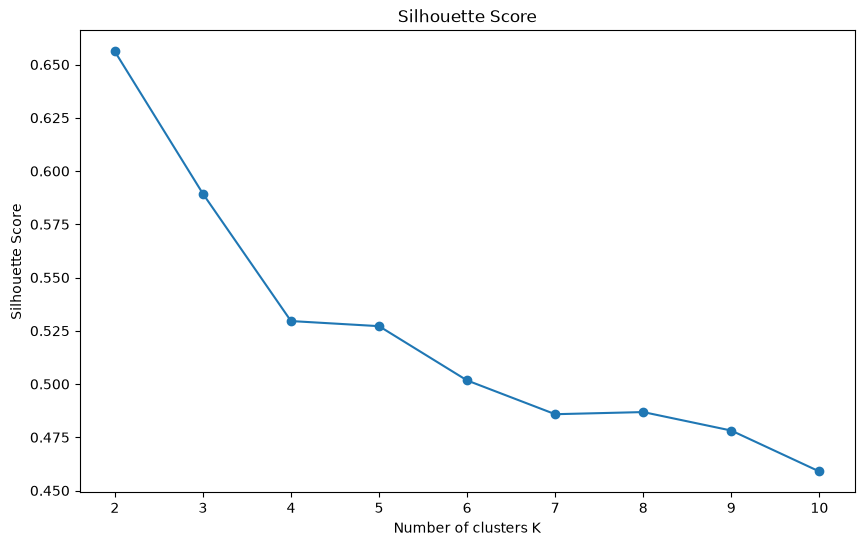

In [69]:
silhouette_scores = []
K_range = range(2, 11)


for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_normalized)
    # Sample 5000 rows for speed
    sample_idx = np.random.choice(len(df_normalized), 5000, replace=False)
    
    score = silhouette_score(df_normalized[sample_idx], labels[sample_idx])
    silhouette_scores.append(score)
    print(f'K={k} done, score={score:.4f}')

plt.figure(figsize=(10, 6))
plt.plot(K_range, silhouette_scores, marker='o')
plt.title('Silhouette Score')
plt.xlabel('Number of clusters K')
plt.ylabel('Silhouette Score')
plt.show()

Higher score = better separated clusters!
K=2 done, score=0.6548 ← HIGHEST!
K=3 done, score=0.6009
K=4 done, score=0.5361
K=5 done, score=0.5242
K=6 done, score=0.5088
K=7 done, score=0.4854
K=8 done, score=0.4777
K=9 done, score=0.4780
K=10 done, score=0.4610


So optimal K = 2!

In [70]:
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(df_normalized)

df['cluster'] = labels

profile = df.groupby('cluster')[['rating', 'price_usd',
    'battery_life_rating', 'age']].mean().round(2)
print(profile)

         rating  price_usd  battery_life_rating    age
cluster                                               
0          3.11     457.67                 2.72  30.02
1          3.11     887.80                 2.73  30.08
2          3.11     688.90                 2.69  30.18
3          3.15     627.45                 2.73  30.04
4          3.12     912.57                 2.72  30.12


| Cluster | Price | Segment Name | Business Action |
|---|---|---|---|
| 4 | $912 | Premium Buyers | Target with flagship phones |
| 1 | $887 | High Spenders | Offer loyalty rewards |
| 2 | $688 | Mid-range | Offer value-for-money deals |
| 3 | $627 | Mid-budget | Offer EMI options |
| 0 | $457 | Budget Buyers | Target with budget phones |

Key observations 
Price separates clusters clearly! 

From $457 to $912 — good separation!

But rating and age are same across all! 

Rating → all ~3.11
Age → all ~30

## Business Insights from Mobile Customer Segmentation

### Segment 1 — Premium Buyers (Cluster 4) 💰
- Average price: $912
- These customers willingly spend on high-end phones
- **Action:** Target with flagship launches, exclusive offers, 
  early access programs and premium after-sales service

### Segment 2 — High Spenders (Cluster 1) 💰
- Average price: $887
- Similar to premium buyers but slightly more price conscious
- **Action:** Offer loyalty rewards, upgrade programs 
  and bundle deals to retain them

### Segment 3 — Mid-range Buyers (Cluster 2) 📱
- Average price: $688
- Largest potential growth segment
- **Action:** Target with value-for-money flagships, 
  highlight camera and performance features

### Segment 4 — Mid-budget Buyers (Cluster 3) 📱
- Average price: $627
- Price sensitive but willing to stretch for right features
- **Action:** Offer EMI options, seasonal discounts 
  and feature-focused marketing

### Segment 5 — Budget Buyers (Cluster 0) 🏷️
- Average price: $457 — largest segment (43,891 customers)
- Most price sensitive group
- **Action:** Target with budget friendly phones, 
  cashback offers and referral programs

### Overall Findings 🔑
- Price is the PRIMARY differentiator across segments
- Rating (~3.1) is consistent across ALL segments — 
  customers judge based on expectations not price!
- Age (~30) is consistent — young adults dominate all segments
- All brands and countries show uniform satisfaction — 
  no single brand dominates customer happiness

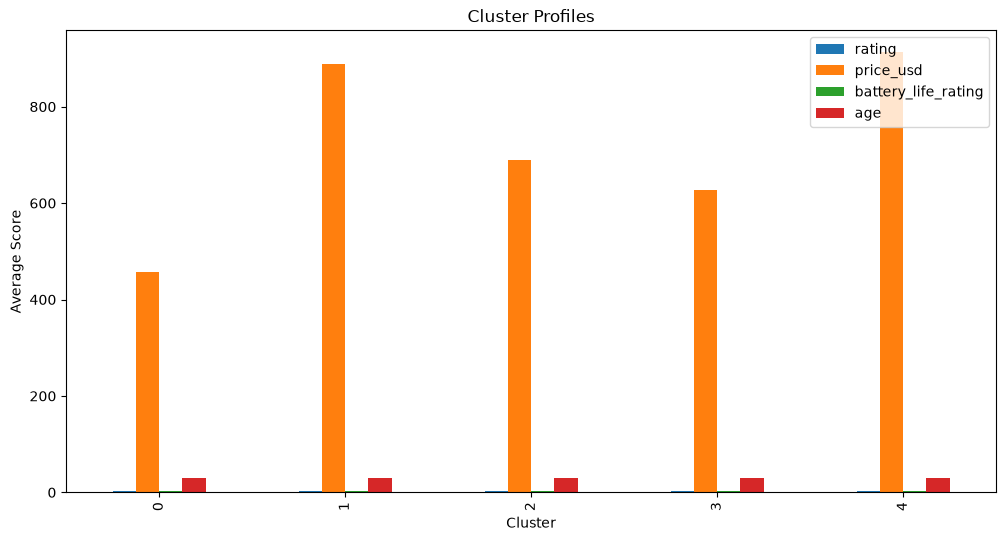

In [71]:
profile.plot(kind='bar', figsize=(12, 6))
plt.title('Cluster Profiles')
plt.xlabel('Cluster')
plt.ylabel('Average Score')
plt.legend(loc='upper right')
plt.show()

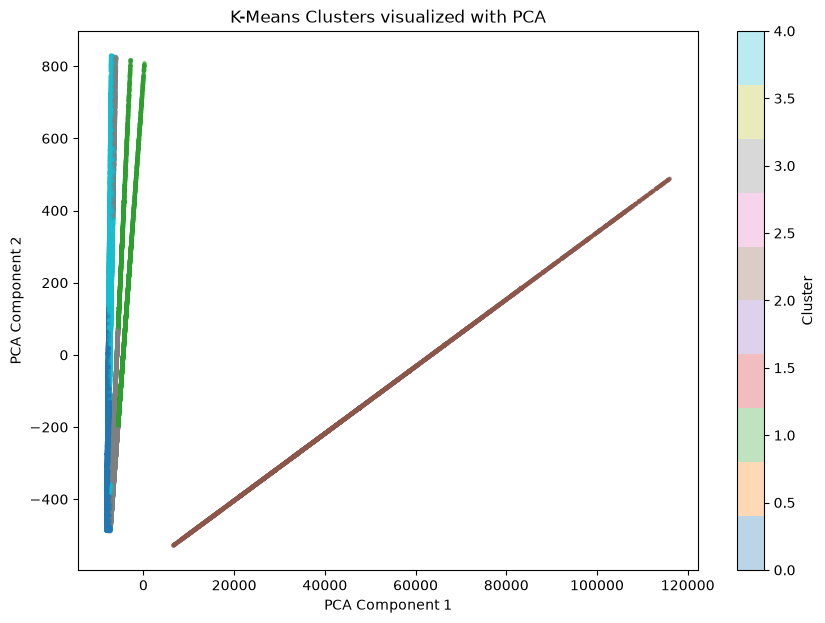

In [72]:
from sklearn.decomposition import PCA

# Reduce to 2 dimensions
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df)

# Plot
plt.figure(figsize=(10, 7))
scatter = plt.scatter(df_pca[:, 0], df_pca[:, 1], 
                      c=df['cluster'], 
                      cmap='tab10',
                      alpha=0.3,
                      s=5)
plt.colorbar(scatter, label='Cluster')
plt.title('K-Means Clusters visualized with PCA')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

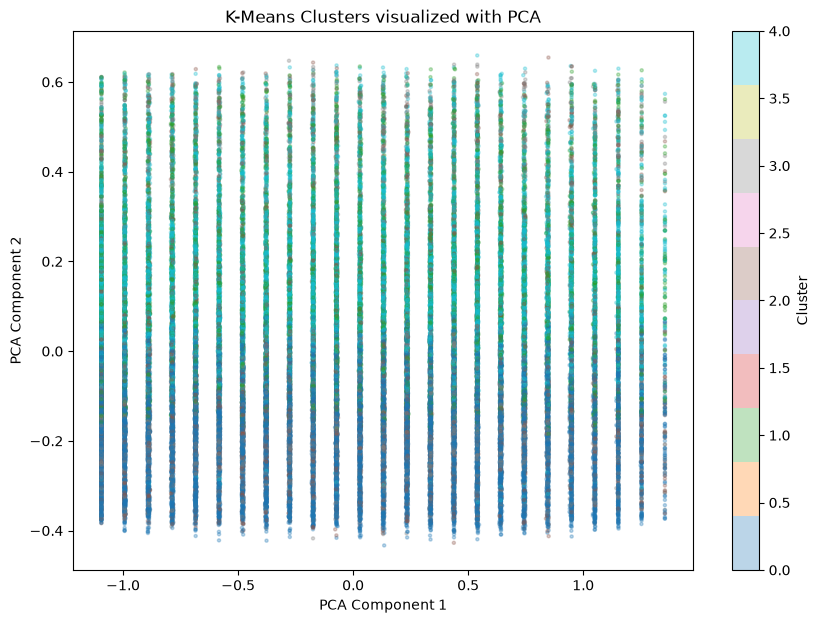

In [73]:
# Use only the key numeric columns
key_cols = ['rating', 'price_usd', 'battery_life_rating', 
            'camera_rating', 'performance_rating', 
            'design_rating', 'display_rating']

from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

# Scale only these columns
scaler = MinMaxScaler()
df_numeric = scaler.fit_transform(df[key_cols])

# PCA on numeric columns only
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_numeric)

# Plot
plt.figure(figsize=(10, 7))
scatter = plt.scatter(df_pca[:, 0], df_pca[:, 1],
                      c=df['cluster'],
                      cmap='tab10',
                      alpha=0.3,
                      s=5)
plt.colorbar(scatter, label='Cluster')
plt.title('K-Means Clusters visualized with PCA')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

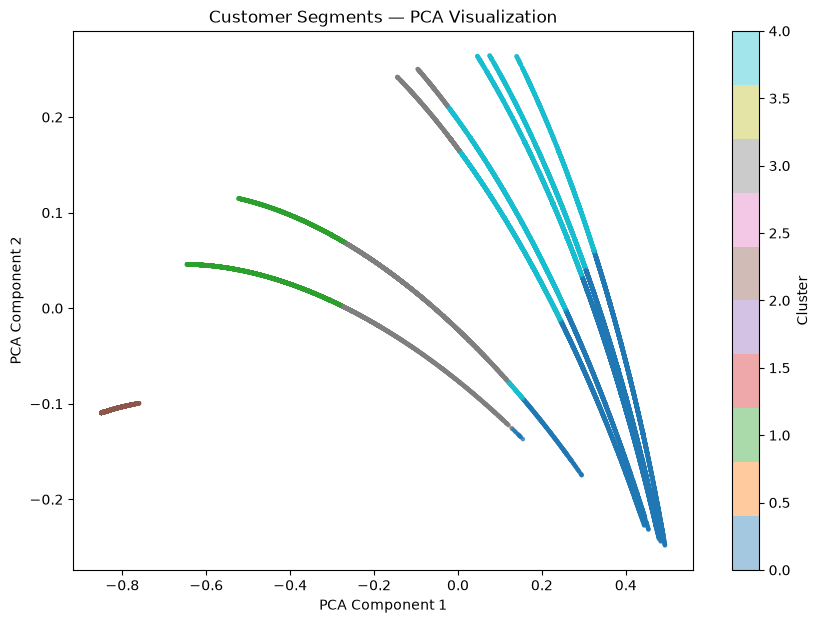

In [74]:
from sklearn.decomposition import PCA

# PCA on normalized data
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_normalized)

# Plot
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    df_pca[:, 0], 
    df_pca[:, 1],
    c=df['cluster'],
    cmap='tab10',
    alpha=0.4,
    s=5
)
plt.colorbar(scatter, label='Cluster')
plt.title('Customer Segments — PCA Visualization')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

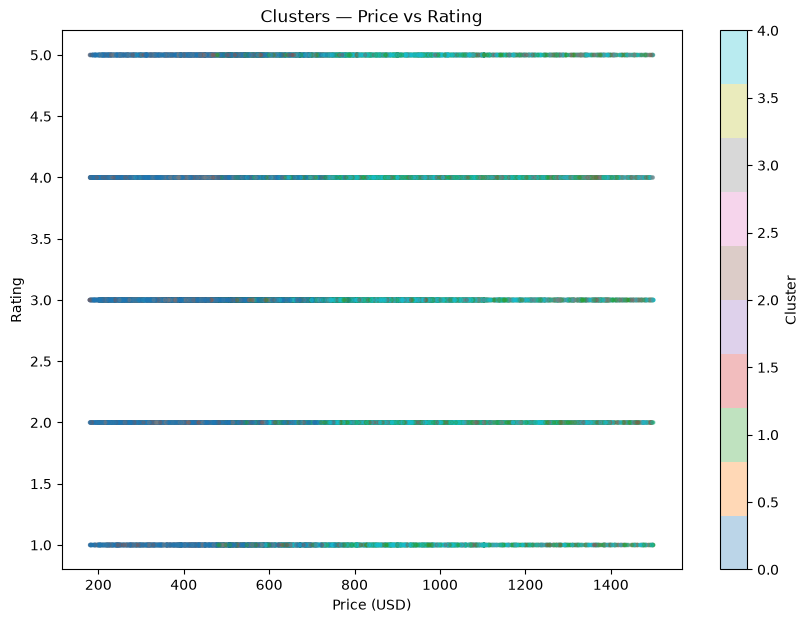

In [75]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    df['price_usd'], 
    df['rating'],
    c=df['cluster'],
    cmap='tab10',
    alpha=0.3,
    s=5
)
plt.colorbar(scatter, label='Cluster')
plt.title('Clusters — Price vs Rating')
plt.xlabel('Price (USD)')
plt.ylabel('Rating')
plt.show()

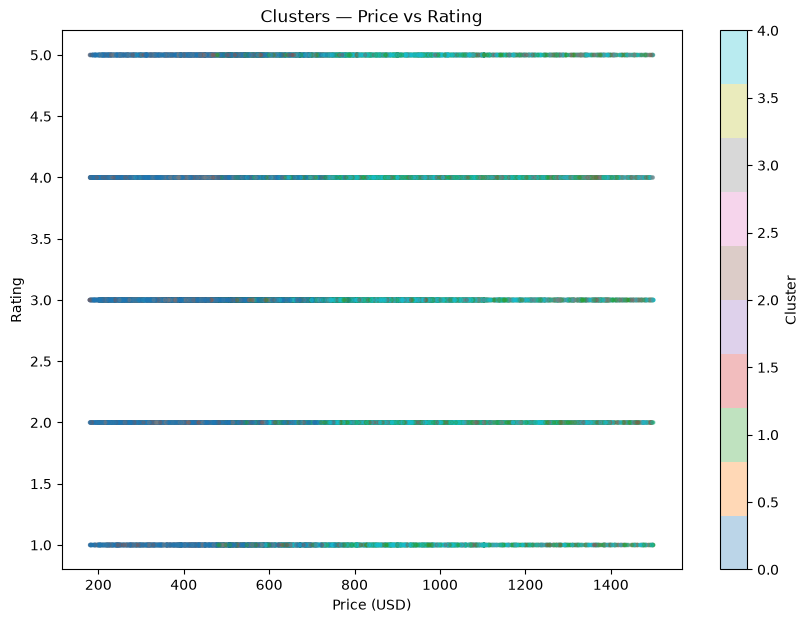

In [76]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    df['price_usd'], 
    df['rating'],
    c=df['cluster'],
    cmap='tab10',
    alpha=0.3,
    s=5
)
plt.colorbar(scatter, label='Cluster')
plt.title('Clusters — Price vs Rating')
plt.xlabel('Price (USD)')
plt.ylabel('Rating')
plt.show()

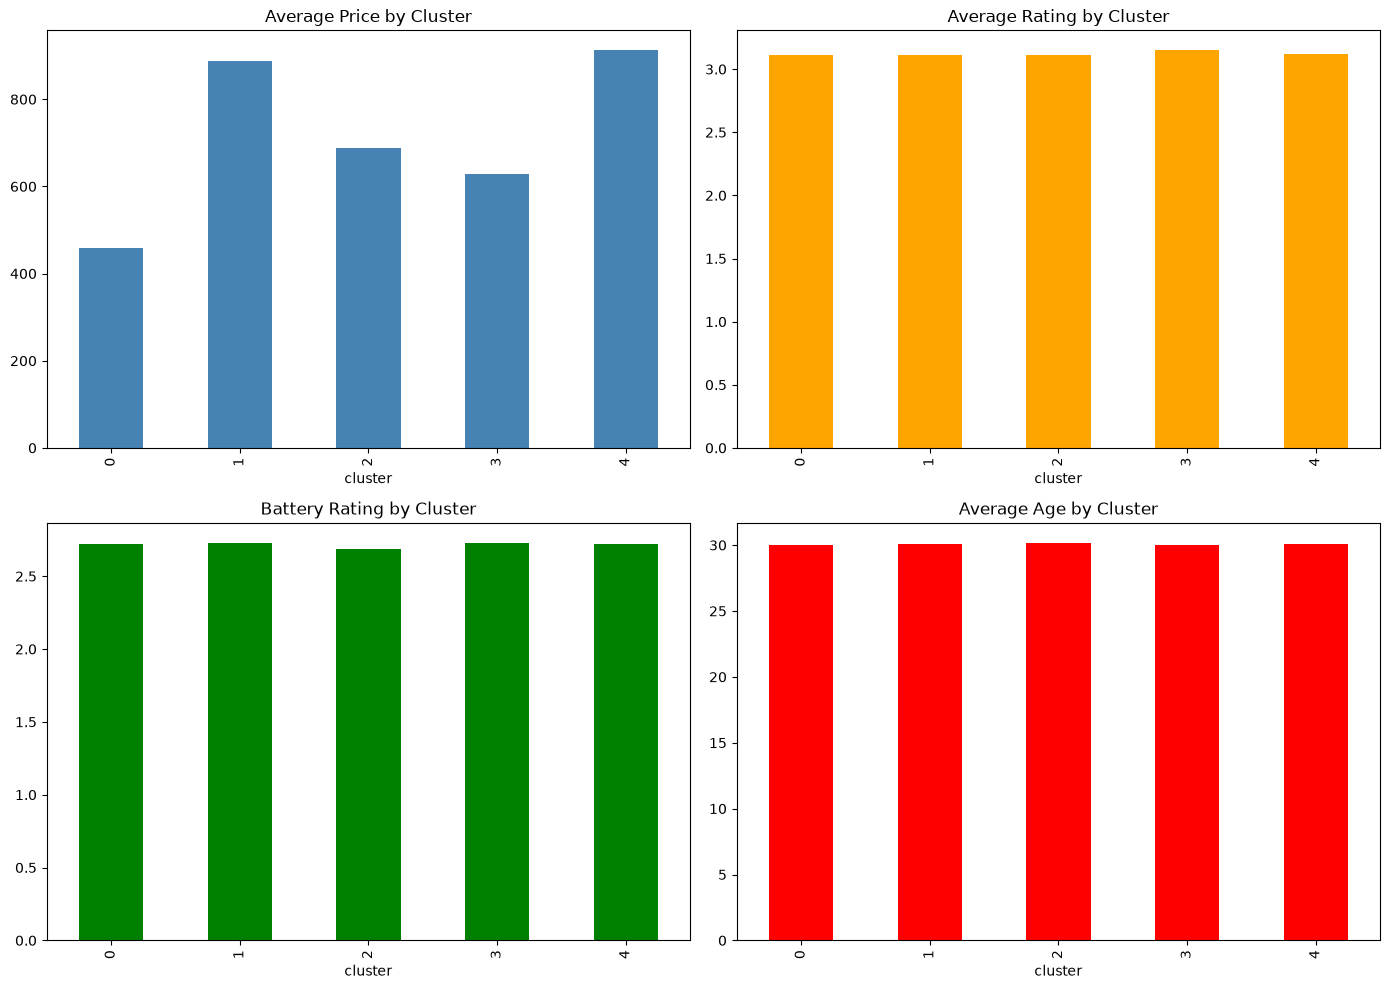

In [77]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

profile['price_usd'].plot(kind='bar', ax=axes[0,0], 
    color='steelblue', title='Average Price by Cluster')

profile['rating'].plot(kind='bar', ax=axes[0,1], 
    color='orange', title='Average Rating by Cluster')

profile['battery_life_rating'].plot(kind='bar', ax=axes[1,0], 
    color='green', title='Battery Rating by Cluster')

profile['age'].plot(kind='bar', ax=axes[1,1], 
    color='red', title='Average Age by Cluster')

plt.tight_layout()
plt.show()